

# СӨЖ
# Сверткалық Нейрондық Желілер (CNN) және CIFAR-10

**Мақсаты:** Сверткалық нейрондық желілердің (CNN) жұмыс істеу принципін түсіну және CIFAR-10 деректер жиынтығындағы түрлі-түсті суреттерді классификациялау үшін модель құру.

**Сіздің тапсырмаңыз:** Төмендегі код ұяшықтарында `# TODO` деп белгіленген жерлерді дұрыс кодпен немесе мәнмен толтыру.




### 1. Қысқаша теория

Сверткалық нейрондық желілер (CNN) – бұл суреттерді өңдеуге арналған ең тиімді архитектура. Ол негізгі үш бөліктен тұрады:

1. **Convolutional Layer (Сверткалық қабат):** Суреттің үстінен кішкентай "сүзгілер" (filters) жүргізу арқылы маңызды белгілерді (сызықтар, бұрыштар, фактуралар) бөліп алады.
* *Функция:* `layers.Conv2D`


2. **Pooling Layer (Пулинг қабаты):** Суреттің өлшемін кішірейтеді, есептеуді жеңілдетеді және маңызды ақпаратты қалдырады. Ең көп тарағаны – Max Pooling (аймақтағы ең үлкен мәнді алу).
* *Функция:* `layers.MaxPooling2D`


3. **Fully Connected Layer (Толық байланысқан қабат):** Соңында табылған белгілерді біріктіріп, суреттің қай класқа жататынын анықтайды.
* *Функция:* `layers.Dense`



Алдымен қажетті кітапханаларды қосайық.

In [8]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Нұсқаны тексеру
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0



### 2. Деректерді жүктеу (CIFAR-10)

Біз **CIFAR-10** датасетін қолданамыз. Онда 10 түрлі класқа жататын 60,000 түрлі-түсті сурет (32x32 пиксель) бар.
Кластар: *'ұшақ', 'автокөлік', 'құс', 'мысық', 'бұғы', 'ит', 'бақа', 'жылқы', 'кеме', 'жүк көлігі'.*


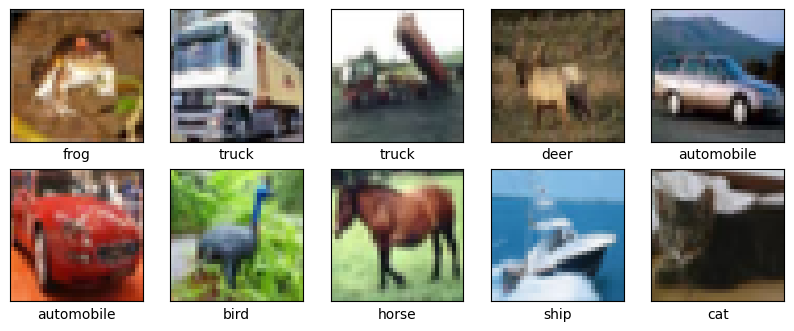

In [9]:
# Деректерді жүктеу
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Пиксель мәндерін 0 мен 1 аралығына келтіру (Нормализация)
# TODO: Студент сурет пиксельдерін нормализациялауы керек (255.0-ге бөлу)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Класс атаулары
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Деректердің дұрыс жүктелгенін тексеру (алғашқы 10 суретті шығару)
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # CIFAR labels массивтер массиві болып табылады, сондықтан қосымша индекс керек
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()


### 3. CNN Архитектурасын құру (Негізгі тапсырма)

Бұл бөлімде сіз нейрондық желінің "қаңқасын" жинайсыз.
Сызба мынадай болуы керек:

1. **Conv2D:** 32 фильтр, (3, 3) өлшем, 'relu' активациясы, кіріс өлшемі (32, 32, 3).
2. **MaxPooling2D:** (2, 2) өлшемі.
3. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
4. **MaxPooling2D:** (2, 2) өлшемі.
5. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
6. **Flatten:** Векторға айналдыру.
7. **Dense:** 64 нейрон, 'relu' активациясы.
8. **Dense (Шығыс):** 10 нейрон (кластар саны).

**Тапсырма:** Төмендегі кодта қалдырылған `# TODO` орындарын толтырыңыз.


In [10]:
model = models.Sequential()

# 1-қабат: Конволюция
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(layers.BatchNormalization())

# 2-қабат: Пулинг
model.add(layers.MaxPooling2D(pool_size=(2, 2)))

# 3-қабат: Конволюция
model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())

# 4-қабат: Пулинг
model.add(layers.MaxPooling2D((2, 2)))

# 5-қабат: Конволюция
model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())

# 6-қабат: Пулинг
model.add(layers.MaxPooling2D((2, 2)))

# 7-қабат: Flatten
model.add(layers.Flatten())

# 8-қабат: Dropout
model.add(layers.Dropout(0.5))

# 9-қабат: Dense
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())

# 10-қабат: Dropout
model.add(layers.Dropout(0.3))

# 11-қабат: Шығыс қабаты
model.add(layers.Dense(10))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)


### 4. Модельді компиляциялау және оқыту

Модель дайын, енді оны оқыту ережелерін бекітуіміз керек.

* **Optimizer:** `adam` (ең танымал оптимизатор).
* **Loss Function:** `SparseCategoricalCrossentropy` (кластар сандармен берілген кезде қолданылады).
* **Metrics:** `accuracy` (дәлдік).

**Тапсырма:** Компиляция және оқыту параметрлерін толтырыңыз.


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [12]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(datagen.flow(train_images, train_labels, batch_size=64),
                    epochs=50,
                    validation_data=(test_images, test_labels))

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 53ms/step - accuracy: 0.3693 - loss: 1.8916 - val_accuracy: 0.4740 - val_loss: 1.4746
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5472 - loss: 1.2726 - val_accuracy: 0.5250 - val_loss: 1.3719
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6028 - loss: 1.1171 - val_accuracy: 0.6415 - val_loss: 1.0083
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6379 - loss: 1.0237 - val_accuracy: 0.6463 - val_loss: 1.0139
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6583 - loss: 0.9653 - val_accuracy: 0.6134 - val_loss: 1.0893
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.6763 - loss: 0.9273 - val_accuracy: 0.6902 - val_loss: 0.8794
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6882 - loss: 0.8917 - val_accuracy: 0.6417 - val_loss: 1.0802
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6950 - loss: 0.8682 - 



### 5. Нәтижелерді бағалау

Модельдің оқу барысында қателіктер қалай азайғанын және дәлдік қалай өскенін график арқылы көрейік.


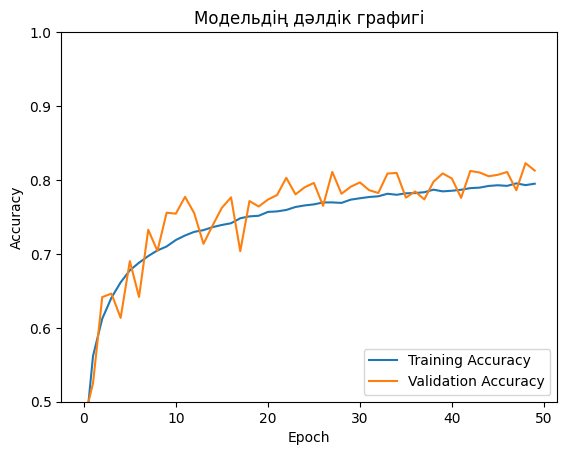

313/313 - 1s - 3ms/step - accuracy: 0.8127 - loss: 0.5482

Модельдің тесттегі дәлдігі: 81.27%


In [13]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Модельдің дәлдік графигі')
plt.show()

# Тест жиынтығындағы соңғы дәлдікті есептеу
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"\nМодельдің тесттегі дәлдігі: {test_acc*100:.2f}%")


### 6. Модельді тексеру (Prediction)

Енді моделіміз нақты суретті қалай танитынын тексерейік. Біз тест жиынтығынан кездейсоқ бір суретті алып, модельге ұсынамыз.


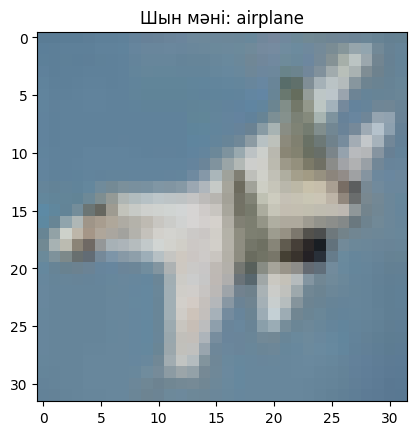

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 881ms/step
Бұл сурет 98.58% ықтималдықпен 'airplane' деп танылды.


In [14]:
# Тест жиынтығынан 10-шы суретті алайық
n = 10

plt.imshow(test_images[n])
plt.title(f"Шын мәні: {class_names[test_labels[n][0]]}")
plt.show()

# Болжам жасау
# Суретті (32,32,3) пішінінен (1, 32, 32, 3) пішініне ауыстыру керек (batch өлшемі)
img_array = np.expand_dims(test_images[n], axis=0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(f"Бұл сурет {100 * np.max(score):.2f}% ықтималдықпен '{class_names[np.argmax(score)]}' деп танылды.")



### Қорытынды сұрақтар

Зертханалық жұмысты қорғау үшін келесі сұрақтарға жауап дайындаңыз:

1. Неліктен біз `Conv2D` қабатын қолданамыз, жай ғана `Dense` қабаттары жеткіліксіз бе?
2. `MaxPooling` қабаты суреттің өлшемін қалай өзгертеді және оның пайдасы неде?
3. Егер `epochs` санын 10-нан 50-ге дейін көбейтсек, нәтиже қалай өзгеруі мүмкін? (Overfitting туралы ойланыңыз).

# Нәтиже дәлдік 90+